### Dataset download ###

In [66]:
import sys
import os
import numpy as np
import pandas as pd
import glob
import tarfile
from pathlib import Path
import cv2
from matplotlib import pyplot as plt

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image
from computervision.imageproc import plot_boxes, enclosing_box, xyxy2xywh, clipxywh, crop_image

from computervision.performance import DetectionMetrics

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Package version: v0.0.2
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


Full data set: https://universe.roboflow.com/shauns-flow/dental-aq0l2

pre-processed: https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz

In [2]:
data_dir = os.environ.get('DATA_DIR')
print(f'data_dir: {data_dir}')
# Directory to store the dentex data set
dataset_name = 'dataset_dental_roboflow'
dataset_dir = os.path.join(data_dir, 'roboflow')
image_dir = os.path.join(dataset_dir, dataset_name)
Path(dataset_dir).mkdir(parents=True, exist_ok=True)

data_dir: /app/data


### Download the data set ###

In [3]:
url_base = 'https://dsets.s3.us-east-1.amazonaws.com/classification_datasets'
url = os.path.join(url_base, f'{dataset_name}.tar.gz')
# The Dentex class in src/computervision/dentex.py contains 
# short methods for working with the dentex data set
# url = os.environ.get('CL_URL')
print(f'Location of the data set for manual download: \n {url}')
file = FileOP().download_from_url(url=url, download_dir=dataset_dir)
if file is not None and os.path.exists(file):
    try:
        with tarfile.open(file) as tar:
            tar.extractall(path=dataset_dir)
    except Exception as e:
        logger.error(f'Failed to extract tar file: {e}')

Location of the data set for manual download: 
 https://dsets.s3.us-east-1.amazonaws.com/classification_datasets/dataset_dental_roboflow.tar.gz
Extracting from .gz archive.
Uncompressed output file exists: /app/data/roboflow/dataset_dental_roboflow.tar. Skipping.


In [69]:
# Open the annotation file (in the image directory after extraction)
annotations_file_name = 'annotations.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)
display(df.head(2))
print(df.shape)

file_col = 'multi_file'
bbox_col= 'bbox'
disease_col = 'disease'
pos_col = 'pos'
label_col = 'label'

# Chceck the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')

,id,license,file_name,height,width,date_captured,file_name_hash,dset,multi_file,bbox,category,disease,pos,box_id
0,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[381.0, 242.0, 481.474, 279.948]",composite,composite,NaN,40762886f4_0
1,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[8.0, 0.0, 130.293, 176.736]",tooth 23,teeth,11.0,40762886f4_1


(12559, 14)
Image directory:        /app/data/roboflow/dataset_dental_roboflow
Total number of images: 993
Annotations:            12559


In [36]:
# Output directory
output_dir = os.path.join(image_dir, 'cropped')
Path(output_dir).mkdir(exist_ok=True, parents=True)

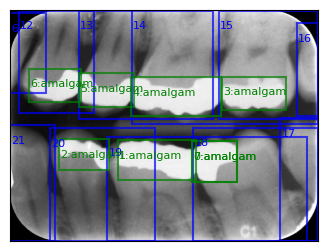

In [136]:
f = 10
file = file_list[f]
file_name = os.path.basename(file)
df_file = df.loc[df[file_col] == file_name].\
    reset_index(drop=True)

# Load the image
im = ImageData().load_image(file)
xlim, ylim = (0, im.shape[1]), (0, im.shape[0])

# Labels and bounding boxes for positions
df_file_position = df_file.loc[~df_file[pos_col].isnull()]
pos_labels = np.int64(df_file_position[pos_col].tolist())
pos_bboxes = df_file_position[bbox_col].tolist()
pos_bboxes = [clipxywh(list(bbox), xlim=xlim, ylim=ylim) for bbox in pos_bboxes]
pos_bbox_dict = dict(zip(pos_labels, pos_bboxes))

# Labels and bounding boxes for diseases
# We need to convert the disease bbox from the xyxy -> xywh format
df_file_disease = df_file.loc[(df_file[pos_col].isnull())]
disease_labels = df_file_disease[disease_col].tolist()
disase_labels_show = [f'{d}:{disease}' for d, disease in enumerate(disease_labels)]
disease_bboxes = df_file_disease[bbox_col].tolist()
disease_bboxes = [clipxywh(xyxy2xywh(list(bbox)), xlim=xlim, ylim=ylim) for bbox in disease_bboxes]

# Plot the image with the bounding boxes
fig, ax = plt.subplots(figsize = (4, 3))
ax = plot_boxes(image=im, box_list=pos_bboxes, label_list=pos_labels, linewidth=1.5, ax=ax, color='b')
ax = plot_boxes(image=im, box_list=disease_bboxes, label_list=disase_labels_show, linewidth=1.5, ax=ax, color='g')
plt.show()

In [82]:
def crop_bbox(bbox, xmin, ymin):
    return [bbox[0] - xmin, bbox[1] - ymin, bbox[2], bbox[3]]

In [147]:
# Loop over the disease labels for this image
crop_df_list = []
disease_pos_list = []

for dix, disease_label in enumerate(disease_labels):

    disease_bbox = disease_bboxes[dix]
    
    # Calculate the overlap with the tooth-bounding boxes
    iou_list = [DetectionMetrics.\
        compute_iou(bbox_1=disease_bbox, bbox_2=bbox, method='np') for bbox in pos_bboxes]
    
    pos_idx_list = [pos_idx for pos_idx in range(len(pos_bboxes)) if iou_list[pos_idx] > 0]
    
    if len(pos_idx_list) > 0:
    
        iou_pos_bboxes = [pos_bboxes[pos_idx] for pos_idx in pos_idx_list]
        
        # Create one bounding box with the teeth affected by the disease
        enclosed_disease_bbox = enclosing_box(bbox_list_xywh=iou_pos_bboxes, offset=20)
        enclosed_disease_bbox = clipxywh(enclosed_disease_bbox, xlim=xlim, ylim=ylim)
        
        # Crop the image by the size of the larger bounging box
        im_cropped = crop_image(image=im, box=enclosed_disease_bbox)
        xmin = enclosed_disease_bbox[0]
        ymin = enclosed_disease_bbox[1]
        
        # Adjust the bounding box coordinates to the new image size
        disease_bbox_cropped = crop_bbox(disease_bbox, xmin=xmin, ymin=ymin)
        iou_pos_bboxes_cropped = [crop_bbox(bbox, xmin=xmin, ymin=ymin) for bbox in iou_pos_bboxes]
        iou_pos_labels = [pos_labels[pos_idx] for pos_idx in pos_idx_list]
        disease_pos_list.extend(iou_pos_labels)
    
        # Save the cropped image
        im_cropped_name = f'{disease_label}_{str(dix).zfill(2)}_{file_name}'
        im_cropped_file = os.path.join(output_dir, im_cropped_name)
        cv2.imwrite(im_cropped_file, cv2.cvtColor(im_cropped, cv2.COLOR_RGB2BGR))    
        
        # Save the bounding box and other data
        crop_dict = {'file_name': im_cropped_name,
                     'width': im_cropped.shape[1],
                     'height': im_cropped.shape[0],
                     'area': im_cropped.shape[0] * im_cropped.shape[1], 
                     label_col: disease_label,
                     bbox_col: [disease_bbox_cropped],
                     pos_col: [iou_pos_labels],
                     'pos_bbox': [iou_pos_bboxes_cropped]}
    
        crop_df_list.append(pd.DataFrame(crop_dict, index=[dix]))
    
        # Plot the image with the bounding box and the label
        #fig, ax = plt.subplots(figsize=(3, 3))
        #ax = plot_boxes(image=im_cropped, box_list=[disease_bbox_cropped], label_list=[disease_label], ax=ax, color='r')
        #ax = plot_boxes(image=im_cropped, box_list=iou_pos_bboxes_cropped, label_list=iou_pos_labels, ax=ax, color='b')
        #plt.show()

# Fix the healthy teeth that do not have a disease label
tooth_list = list(sorted(set(pos_labels).difference(disease_pos_list)))
disease_label = 'tooth'

for p, pos in enumerate(tooth_list):
    pos_bbox = pos_bbox_dict.get(pos)
    im_cropped = crop_image(image=im, box=pos_bbox)
    im_cropped_name = f'{disease_label}_{str(pos).zfill(2)}_{file_name}'
    im_cropped_file = os.path.join(output_dir, im_cropped_name)
    cv2.imwrite(im_cropped_file, cv2.cvtColor(im_cropped, cv2.COLOR_RGB2BGR))
    # Save the bounding box and other data
    crop_dict = {'file_name': im_cropped_name,
                 'width': im_cropped.shape[1],
                 'height': im_cropped.shape[0],
                 'area': im_cropped.shape[0] * im_cropped.shape[1], 
                 label_col: disease_label,
                 bbox_col: np.nan,
                 pos_col: pos,
                 'pos_bbox': np.nan}
    
    
    crop_df_list.append(pd.DataFrame(crop_dict, index=[p]))

crop_df_image = pd.concat(crop_df_list, axis=0, ignore_index=True)
crop_df_image.insert(loc=0, column=file_col, value=file_name)

In [148]:
crop_df_image

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox
0,26306a4fb9.jpg,amalgam_00_26306a4fb9.jpg,458,256,117248,amalgam,"[196, 48, 94, 84]","[18, 19]","[[198, 20, 260, 236], [20, 40, 414, 216]]"
1,26306a4fb9.jpg,amalgam_01_26306a4fb9.jpg,577,256,147712,amalgam,"[161, 46, 163, 83]","[18, 19, 20]","[[317, 20, 260, 236], [139, 40, 414, 216], [20..."
2,26306a4fb9.jpg,amalgam_02_26306a4fb9.jpg,573,255,146115,amalgam,"[39, 43, 104, 63]","[19, 20]","[[139, 39, 414, 216], [20, 20, 218, 235]]"
3,26306a4fb9.jpg,amalgam_03_26306a4fb9.jpg,408,257,104856,amalgam,"[208, 138, 133, 69]","[15, 14]","[[201, 1, 207, 224], [20, 0, 388, 237]]"
4,26306a4fb9.jpg,amalgam_04_26306a4fb9.jpg,518,257,133126,amalgam,"[129, 139, 187, 80]","[15, 14, 13]","[[311, 1, 207, 224], [130, 0, 388, 237], [20, ..."
5,26306a4fb9.jpg,amalgam_05_26306a4fb9.jpg,640,257,164480,amalgam,"[143, 131, 115, 71]","[14, 13, 12]","[[252, 0, 388, 237], [142, 1, 279, 224], [18, ..."
6,26306a4fb9.jpg,amalgam_06_26306a4fb9.jpg,441,245,108045,amalgam,"[39, 122, 107, 68]","[13, 12, 6]","[[142, 1, 279, 224], [18, 1, 156, 213], [0, 6,..."
7,26306a4fb9.jpg,amalgam_07_26306a4fb9.jpg,458,256,117248,amalgam,"[196, 48, 94, 84]","[18, 19]","[[198, 20, 260, 236], [20, 40, 414, 216]]"
8,26306a4fb9.jpg,tooth_16_26306a4fb9.jpg,45,192,8640,tooth,NaN,16,NaN
9,26306a4fb9.jpg,tooth_17_26306a4fb9.jpg,79,256,20224,tooth,NaN,17,NaN


In [131]:
print(sorted(pos_labels))
print(sorted(list(set(disease_pos_list))))

[6, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
[6, 12, 13, 14, 15, 18, 19, 20]


In [132]:
tooth_list

{16, 17, 21}

In [112]:
pd.concat(crop_df_list)

,multi_file,label,bbox,pos,pos_bbox
0,amalgam_00_26306a4fb9.jpg,amalgam,"[196, 48, 94, 84]","[18, 19]","[[198, 20, 260, 236], [20, 40, 414, 216]]"
1,amalgam_01_26306a4fb9.jpg,amalgam,"[161, 46, 163, 83]","[18, 19, 20]","[[317, 20, 260, 236], [139, 40, 414, 216], [20..."
2,amalgam_02_26306a4fb9.jpg,amalgam,"[39, 43, 104, 63]","[19, 20]","[[139, 39, 414, 216], [20, 20, 218, 235]]"
3,amalgam_03_26306a4fb9.jpg,amalgam,"[208, 138, 133, 69]","[15, 14]","[[201, 1, 207, 224], [20, 0, 388, 237]]"
4,amalgam_04_26306a4fb9.jpg,amalgam,"[129, 139, 187, 80]","[15, 14, 13]","[[311, 1, 207, 224], [130, 0, 388, 237], [20, ..."
5,amalgam_05_26306a4fb9.jpg,amalgam,"[143, 131, 115, 71]","[14, 13, 12]","[[252, 0, 388, 237], [142, 1, 279, 224], [18, ..."
6,amalgam_06_26306a4fb9.jpg,amalgam,"[39, 122, 107, 68]","[13, 12, 6]","[[142, 1, 279, 224], [18, 1, 156, 213], [0, 6,..."
7,amalgam_07_26306a4fb9.jpg,amalgam,"[196, 48, 94, 84]","[18, 19]","[[198, 20, 260, 236], [20, 40, 414, 216]]"


In [98]:
im_cropped.shape

(0, 408, 3)